![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 1. Waveguides

Welcome to our Photonic Integrated Circuits Laboratory! Throughout the course, we will be using a Python package called [GDSFactory](https://gdsfactory.github.io/gdsfactory/index.html). This is an open-source tool, and is a great alternative to other commercial software like Synopsys Optodesigner, Luceda Photonics, or Lumerical/Interconnect. Since it runs on Python, you have two options for executing your laboratory tasks:

1. **Local installation on your own PC** (Recommended): Please note that we will not spend class time on installing the software. However, feel free to reach out if you need help with the installation.

2. **Cloud Workspace**: Alternatively, you can use a cloud-based solution if the Local installation does not work.

## 0. Imports

For this laboratory you will need the following libraries:

In [24]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength


## LO.1. Effective index of a waveguide

### 1.1. Materials

We need the refractive index of each material in the cross-section. There are different options to get this information, such as [RefractiveIndex.info](https://refractiveindex.info/) and the [Material Library from Tidy3D](https://docs.flexcompute.com/projects/tidy3d/en/v2.6.0/api/material_library.html#). Here we will load and check the characteristics from the most common materials used in fabrication of photonic circuits: **silicon (Si), silicon nitride (SiNx) and silicon dioxide (SiO2)**.

#### 1.1.1. Crystalline Silicon 

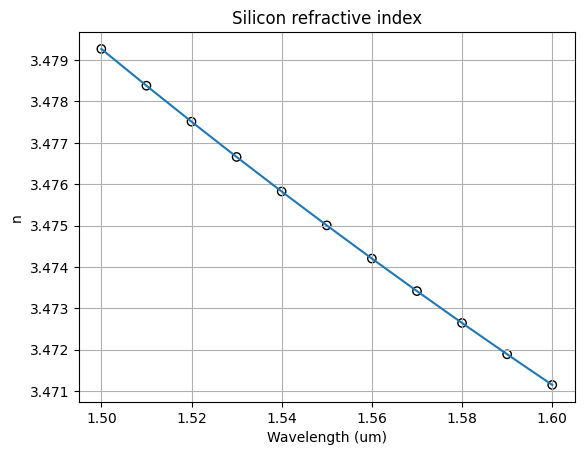

In [25]:
## Material model loaded
si_complex = td.material_library["cSi"]["Li1993_293K"].eps_model(f)
## Check the Tidy3D Docs for more information on the "Variant"

## Index at a particular wavelength
si_index , si_k = td.Medium.eps_complex_to_nk(si_complex)
plt.scatter(wavelength, si_index,edgecolors='k',facecolors='none')
plt.plot(wavelength,si_index)
plt.title("Silicon refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()

#### 1.1.2. Silicon Nitride

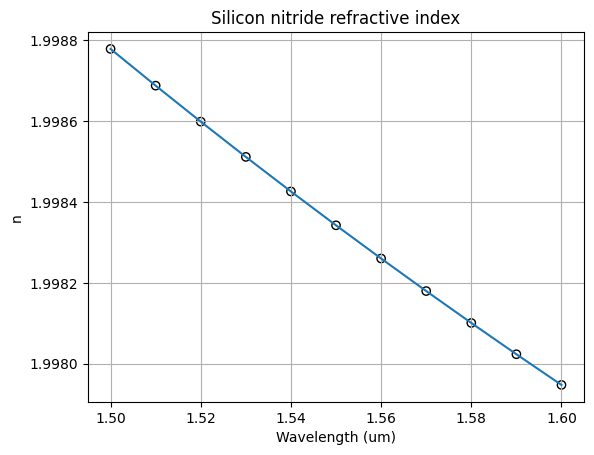

In [26]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
plt.scatter(wavelength,nitride_index,edgecolors='k',facecolors='none')
plt.plot(wavelength, nitride_index)
plt.title("Silicon nitride refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()


#### 1.1.3. Silicon Dioxide

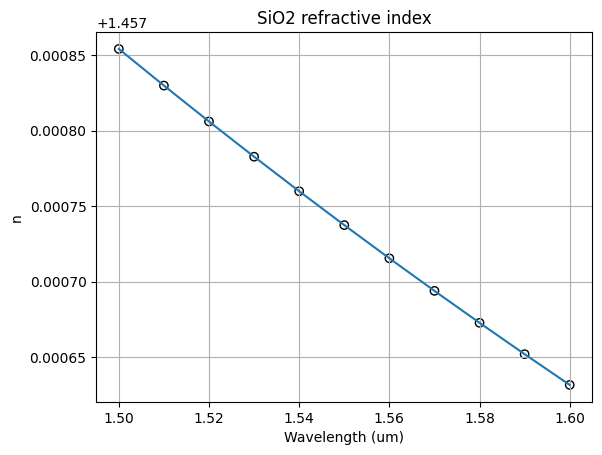

In [27]:
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)
plt.scatter(wavelength,box_index,edgecolors='k',facecolors='None')
plt.plot(wavelength, box_index)
plt.title("SiO2 refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()

### 1.2. Cross - Section Definition

In GDSFactory - Tidy3d modesolver we just have to use the [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. 
It implements the **deep (rib)** and **shallow (ridge)** waveguide variants. The following example corresponds to a **deep** waveguide for the **silicon nitride** fabrication proccess, this means that the **cladding** material is silicon dioxide and the **core** material is silicon nitride. The waveguide dimensions are 300 nm (height) and 1.2 um (width). We will check it's behavior at 1.55 um. 

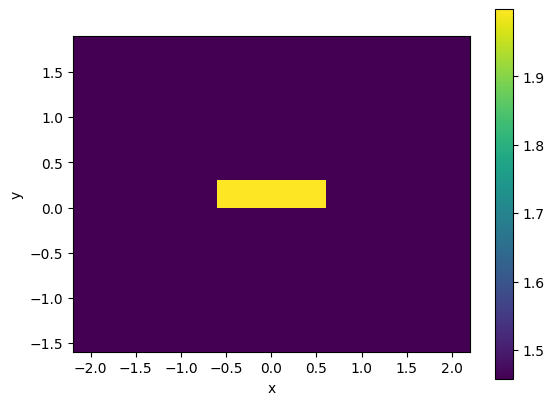

In [28]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=1.2, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

deep_waveguide.plot_index()

### 1.3. Simulations

#### 1.3.1. Numerical results

We can find the effective index (n_eff), TE and TM fraction for each particular cross-section.

In [29]:
deep_waveguide.n_eff
print("Effective indices of the modes: ", deep_waveguide.n_eff)

2026-03-12 14:01:42.577 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cf92515ae4232c65.npz.
Effective indices of the modes:  [1.60524792+0.00010066j 1.52829803+0.00017753j 1.45072999+0.00019228j
 1.43325817+0.00021838j]


De los 4 modos, solo se propagan 2 , ya que en los modos 3 y 4 el indice efectivo o supera 1.457 que se corresponde con el indice de la cubierta de la guía.

In [30]:
deep_waveguide.fraction_te
print("Fraction of the mode that is TE polarized: ", deep_waveguide.fraction_te)

Fraction of the mode that is TE polarized:  [0.99505426 0.01004259 0.96264794 0.047651  ]


Solo se propaga el modo TE0

In [31]:
deep_waveguide.fraction_tm
print("Fraction of the mode that is TM polarized: ", deep_waveguide.fraction_tm)

Fraction of the mode that is TM polarized:  [0.00494574 0.98995741 0.03735206 0.952349  ]


TM0 , los demas no se transmiten

#### 1.3.4. Plots

Text(0, 0.5, 'y (um)')

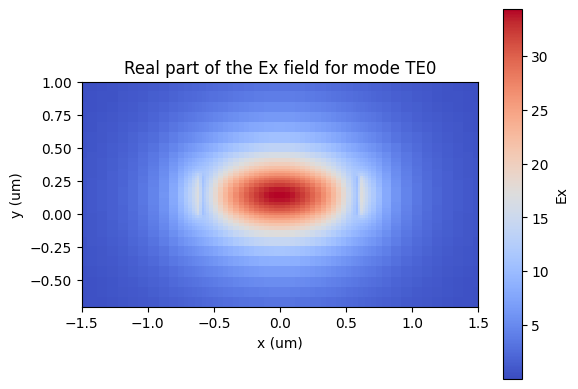

In [32]:
deep_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 
#plt.title('Titulo') # You might need this later :) 
plt.title('Real part of the Ex field for mode TE0')
plt.xlabel('x (um)')
plt.ylabel('y (um)')

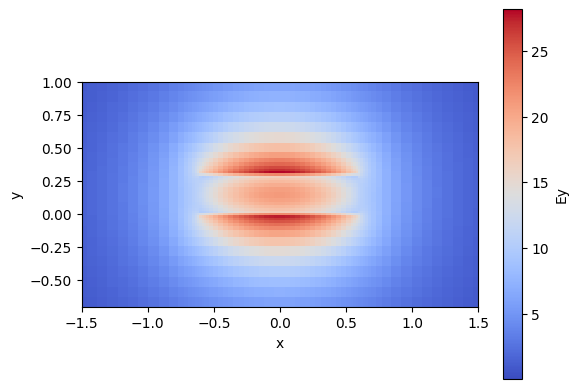

In [33]:
deep_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

Mayor interacion con la cubierta en el modo TM0

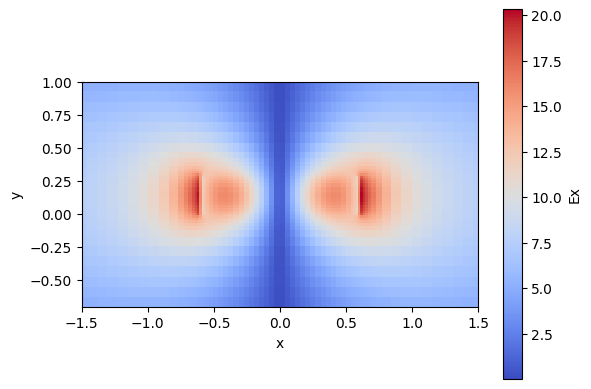

In [34]:
deep_waveguide.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='abs', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

Modo TE1

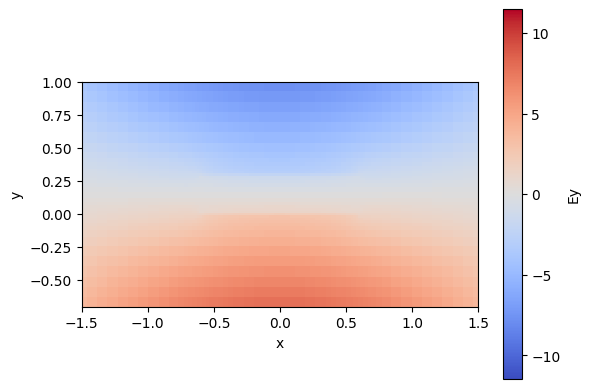

In [35]:
deep_waveguide.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

**Important** 
These results are derived from a numerical method used to solve the EM problem, so they must always be interpreted carefully to assess their accuracy. You must check, for instance, if the value of each index neff is higher than the refractive index of the cladding. 

## LO.2. Wavelength behavior

- Let's find the wavelength dependence of the effective index of the SiNx deep waveguide described in LO1. Change the wavelength used at the waveguide cross-section function, it could be a vector also. 

2026-03-12 14:01:43.595 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e70065e5b5dc42c3.npz.


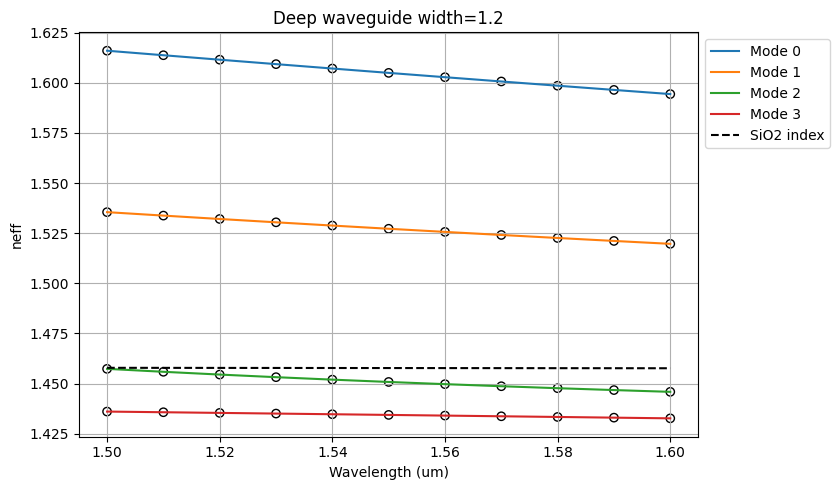

In [36]:
# The wavelength could be a vector also
wavelength = np.linspace(1500, 1600, 11) * nm # Student code here. Tip np.linspace()

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=1.2, 
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

res_neff = deep_waveguide.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = deep_waveguide.fraction_te # Wavelength-dependent vector
res_tm =deep_waveguide.fraction_tm # Wavelength-dependent vector

plt.figure(figsize=(10, 5))
for k in range(res_neff.shape[1]):
    # It's necessary to 'access' each element on the array
    plt.scatter(wavelength, res_neff[:,k].real,edgecolors='k',facecolors='none',label = '__nolegend__')
    plt.plot(wavelength, res_neff[:,k].real,label=f'Mode {k}')
plt.title(f"Deep waveguide width={1.2}")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
# Common error: The box index variable was created in a previous cell. Check the dimensions match 
# with the newly created wavelength vector, or re-calculate the box index for the new one. 
plt.plot(wavelength, box_index,'k--', label='SiO2 index') 
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

- Repeat the analysis for a **shallow**ly etched waveguide with a 150 nm slab heigth. 

2026-03-12 14:01:43.891 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cf0af488213d9e23.npz.


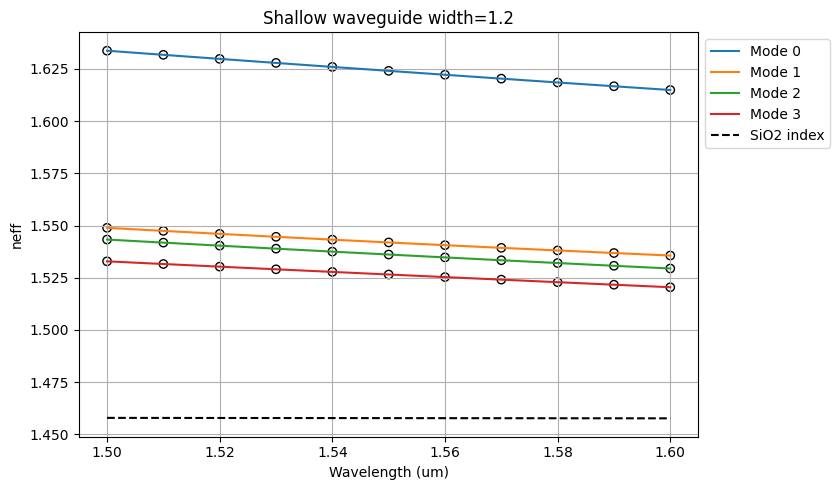

In [37]:
# The wavelength could be a vector also
#wavelength = np.linspace(1500, 1600, 11) * nm # Student code here. Tip np.linspace()

Shallow_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=1.2, 
    slab_thickness=0.15,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

res_neff = Shallow_waveguide.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = Shallow_waveguide.fraction_te # Wavelength-dependent vector
res_tm =Shallow_waveguide.fraction_tm # Wavelength-dependent vector

plt.figure(figsize=(10, 5))
for k in range(res_neff.shape[1]):
    # It's necessary to 'access' each element on the array
    plt.scatter(wavelength, res_neff[:,k].real,edgecolors='k',facecolors='none',label = '__nolegend__')
    plt.plot(wavelength, res_neff[:,k].real,label=f'Mode {k}')
plt.title(f"Shallow waveguide width={1.2}")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
# Common error: The box index variable was created in a previous cell. Check the dimensions match 
# with the newly created wavelength vector, or re-calculate the box index for the new one. 
plt.plot(wavelength, box_index,'k--', label='SiO2 index') 
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

## LO.3. Width dependence

- Perform a sweep of the **deep** waveguide width. Use the code provided in the following cell or program your own sweep. 

  0%|          | 0/11 [00:00<?, ?it/s]

2026-03-12 14:01:44.173 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e0f2a62752cad497.npz.
2026-03-12 14:01:44.178 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cad20f99025f789a.npz.
2026-03-12 14:01:44.185 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_575965d134f345c4.npz.
2026-03-12 14:01:44.195 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_3ca61e62fe85ccf2.npz.
2026-03-12 14:01:44.203 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_8b617c8aef408673.npz.
2026-03-12 14:01:44.210 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cd84020834745298.npz.
2026-03-12 14:01:44.220 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_df7667b1ace5cc7e.npz.
2026-03-12 14:01:44.224 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a4e198a34f8f1987.npz.


  0%|          | 0/11 [00:00<?, ?it/s]

2026-03-12 14:01:44.282 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e0f2a62752cad497.npz.
2026-03-12 14:01:44.286 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cad20f99025f789a.npz.
2026-03-12 14:01:44.296 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_575965d134f345c4.npz.
2026-03-12 14:01:44.300 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_3ca61e62fe85ccf2.npz.
2026-03-12 14:01:44.308 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_8b617c8aef408673.npz.
2026-03-12 14:01:44.313 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cd84020834745298.npz.
2026-03-12 14:01:44.315 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_df7667b1ace5cc7e.npz.
2026-03-12 14:01:44.320 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a4e198a34f8f1987.npz.


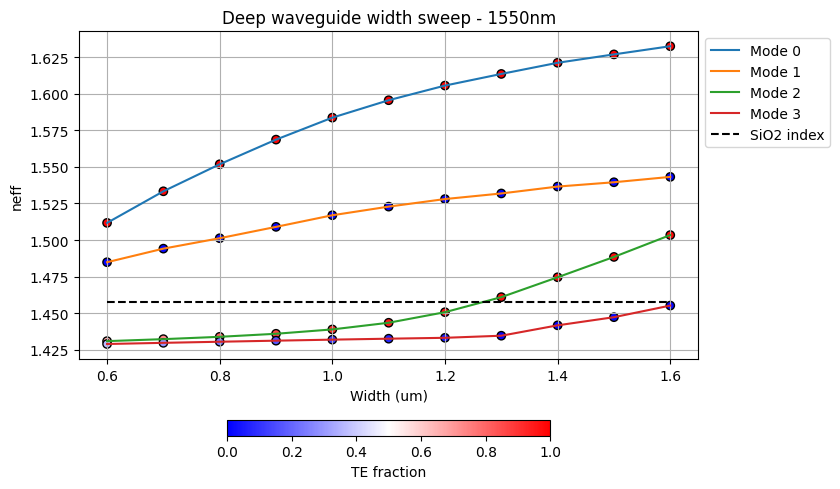

In [38]:
wavelength = 1.55

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=1.2,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

w = np.linspace(0.6, 1.6, 11) # Student code here

sweep_neff = gt.modes.sweep_n_eff(deep_waveguide, 
                             core_width=w)

sweep_tefraction = gt.modes.sweep_fraction_te(deep_waveguide,
                                              core_width=w)

plt.figure(figsize=(10, 5))
for k in range(sweep_neff.shape[1]):
    plt.scatter(w, sweep_neff[:,k].real,edgecolors='k',c=sweep_tefraction.sel(mode_index=k),vmin=0, vmax=1,label = '__nolegend__',cmap='bwr')
    plt.plot(w, sweep_neff[:,k].real,label=f'Mode {k}')

plt.title("Deep waveguide width sweep - 1550nm")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w), xmax=np.max(w), colors='k', linestyles='dashed',label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal',fraction=0.04).set_label("TE fraction")

## LO.4. Waveguide compact model

A compact model of an integrated photonic waveguide is a reduced-order mathematical model that describes the waveguide’s optical behavior—such as phase propagation, loss, and dispersion, using analytical or semi-analytical equations. Consider: 

Consider: 

The transfer function for propagation in a waveguide:

$$
H(\lambda)
= e^{-j\,\gamma(\lambda)\,z}
= e^{-j\,\mathrm{Re}\{\gamma(\lambda)\}\,z}\,
  e^{\mathrm{Im}\{\gamma(\lambda)\}\,z}.
$$

Where 

$$
\beta(\lambda) = \mathrm{Re}\{\gamma(\lambda)\}\,z
= \frac{2\pi}{\lambda}\,n_\mathrm{eff}(\lambda).
$$

Let's model the waveguide's effective index wavelength variation using a second order polynomial:

$$
n_\mathrm{eff}(\lambda)
= n_{1} + n_{2}\,(\lambda-\lambda_{0}) + n_{3}\,(\lambda-\lambda_{0})^{2}
$$

Where 

1. 
$$
n_\mathrm{eff}(\lambda_0) = n_1
$$
2. 
$$
n_g(\lambda_0) = n_1 - n_2\,\lambda_0
$$
3. 
$$
D = -\frac{2\,\lambda_0\,n_3}{c}\;\;[\mathrm{s}^2/\mathrm{m}]
$$

- Find the values for n, ng and D of the following waveguides: 
    - Deep waveguide, height = 300nm, width = 1.2um 
    - Shallow waveguide, core height = 300nm, slab height = 150 nm, width = 1.2um 

**TIP**. Use the Lab0.1.Modesolver results (neff vs lambda) as starting point. Fit the results using a second order polynomial (with the lambda_0 shift) and relate the fit results to n_g and D values.

In [39]:
# STUDENT! Put your code here.

# Wavelength sweep
wavelength = np.linspace(1500, 1600, 11) * nm
lambda0 = 1.55
lambda0_m = lambda0 * 1e-6
wavelength_m = wavelength * 1e-6

Deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=1.2,
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=2,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)

Shallow_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=1.2,
    slab_thickness=0.15,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=2,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)

Deep waveguide - TE0
n1 = 1.6049166291026742
n2 = -216176.94948863686 [1/m]
n3 = 97355065716.41905 [1/m^2]
ng = 1.9399909008100613
D  = -1.0066987866682727e-09

Deep waveguide - TM0
n1 = 1.5271892343287958
n2 = -157958.78292764197 [1/m]
n3 = 153831713240.62677 [1/m^2]
ng = 1.7720253478666408
D  = -1.590694823436629e-09

Shallow waveguide - TE0
n1 = 1.6240906297465494
n2 = -188174.89158080934 [1/m]
n3 = 95695802708.36765 [1/m^2]
ng = 1.915761711696804
D  = -9.895411991850032e-10

Shallow waveguide - TM0
n1 = 1.5418953644015398
n2 = -132598.50322921542 [1/m]
n3 = 148011675415.50256 [1/m^2]
ng = 1.7474230444068237
D  = -1.530512798250775e-09
2026-03-12 14:01:44.616 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_651c08b700f375c8.npz.


2026-03-12 14:01:44.618 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_622183ae5d2fe13f.npz.


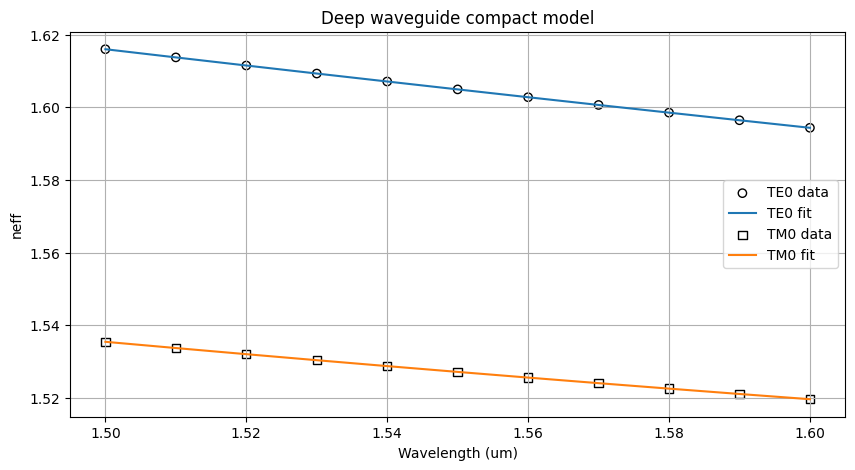

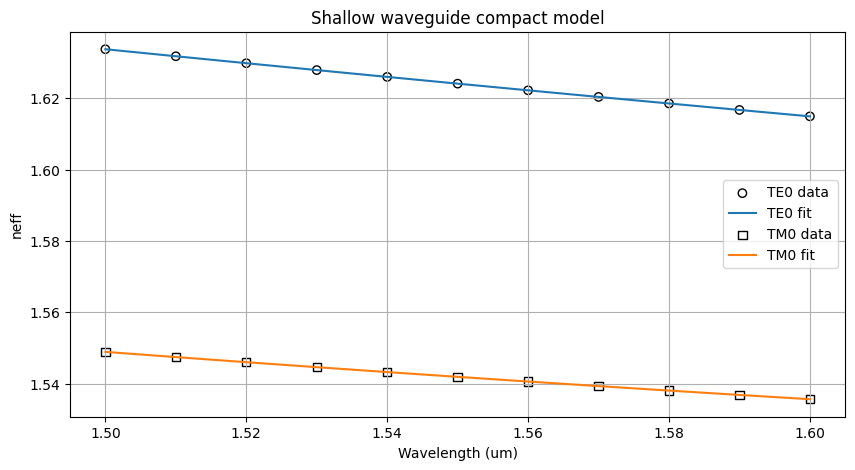

In [40]:
def order_neff_array(neff, n_wavelengths):
    neff = np.array(neff).real
    if neff.ndim == 1:
        neff = neff[:, None]
    if neff.shape[0] != n_wavelengths:
        neff = neff.T
    return neff

def fit_compact_model(wavelength_m, neff_mode, lambda0_m):
    x = wavelength_m - lambda0_m
    n3, n2, n1 = np.polyfit(x, neff_mode, 2)

    ng = n1 - n2 * lambda0_m
    D = -2 * lambda0_m * n3 / td.C_0

    return n1, n2, n3, ng, D

def compact_model_eval(wavelength_m, lambda0_m, n1, n2, n3):
    x = wavelength_m - lambda0_m
    return n1 + n2 * x + n3 * x**2


deep_neff = order_neff_array(Deep_waveguide.n_eff, len(wavelength))
shallow_neff = order_neff_array(Shallow_waveguide.n_eff, len(wavelength))

deep_te0 = deep_neff[:, 0]
deep_tm0 = deep_neff[:, 1]

shallow_te0 = shallow_neff[:, 0]
shallow_tm0 = shallow_neff[:, 1]


# Deep waveguide
n1_deep_te0, n2_deep_te0, n3_deep_te0, ng_deep_te0, D_deep_te0 = fit_compact_model(
    wavelength_m, deep_te0, lambda0_m
)
n1_deep_tm0, n2_deep_tm0, n3_deep_tm0, ng_deep_tm0, D_deep_tm0 = fit_compact_model(
    wavelength_m, deep_tm0, lambda0_m
)

# Shallow waveguide
n1_shallow_te0, n2_shallow_te0, n3_shallow_te0, ng_shallow_te0, D_shallow_te0 = fit_compact_model(
    wavelength_m, shallow_te0, lambda0_m
)
n1_shallow_tm0, n2_shallow_tm0, n3_shallow_tm0, ng_shallow_tm0, D_shallow_tm0 = fit_compact_model(
    wavelength_m, shallow_tm0, lambda0_m
)


print("Deep waveguide - TE0")
print("n1 =", n1_deep_te0)
print("n2 =", n2_deep_te0, "[1/m]")
print("n3 =", n3_deep_te0, "[1/m^2]")
print("ng =", ng_deep_te0)
print("D  =", D_deep_te0)
print()

print("Deep waveguide - TM0")
print("n1 =", n1_deep_tm0)
print("n2 =", n2_deep_tm0, "[1/m]")
print("n3 =", n3_deep_tm0, "[1/m^2]")
print("ng =", ng_deep_tm0)
print("D  =", D_deep_tm0)
print()

print("Shallow waveguide - TE0")
print("n1 =", n1_shallow_te0)
print("n2 =", n2_shallow_te0, "[1/m]")
print("n3 =", n3_shallow_te0, "[1/m^2]")
print("ng =", ng_shallow_te0)
print("D  =", D_shallow_te0)
print()

print("Shallow waveguide - TM0")
print("n1 =", n1_shallow_tm0)
print("n2 =", n2_shallow_tm0, "[1/m]")
print("n3 =", n3_shallow_tm0, "[1/m^2]")
print("ng =", ng_shallow_tm0)
print("D  =", D_shallow_tm0)


# Plot for deep waveguide
plt.figure(figsize=(10, 5))

plt.scatter(wavelength, deep_te0, edgecolors='k', facecolors='none', label='TE0 data')
plt.plot(
    wavelength,
    compact_model_eval(wavelength_m, lambda0_m, n1_deep_te0, n2_deep_te0, n3_deep_te0),
    label='TE0 fit'
)

plt.scatter(wavelength, deep_tm0, edgecolors='k', facecolors='none', marker='s', label='TM0 data')
plt.plot(
    wavelength,
    compact_model_eval(wavelength_m, lambda0_m, n1_deep_tm0, n2_deep_tm0, n3_deep_tm0),
    label='TM0 fit'
)

plt.title("Deep waveguide compact model")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
plt.legend()
plt.show()


# Plot for shallow waveguide
plt.figure(figsize=(10, 5))

plt.scatter(wavelength, shallow_te0, edgecolors='k', facecolors='none', label='TE0 data')
plt.plot(
    wavelength,
    compact_model_eval(wavelength_m, lambda0_m, n1_shallow_te0, n2_shallow_te0, n3_shallow_te0),
    label='TE0 fit'
)

plt.scatter(wavelength, shallow_tm0, edgecolors='k', facecolors='none', marker='s', label='TM0 data')
plt.plot(
    wavelength,
    compact_model_eval(wavelength_m, lambda0_m, n1_shallow_tm0, n2_shallow_tm0, n3_shallow_tm0),
    label='TM0 fit'
)

plt.title("Shallow waveguide compact model")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
plt.legend()
plt.show()

## LO.5. Bend waveguide radius vs. loss – deep



The bend loss has three primary contributions:

1. Mode-mismatch loss
2. Radiation loss
3. Propagation loss

2026-03-12 14:01:44.855 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1592dba1d8e935a8.npz.


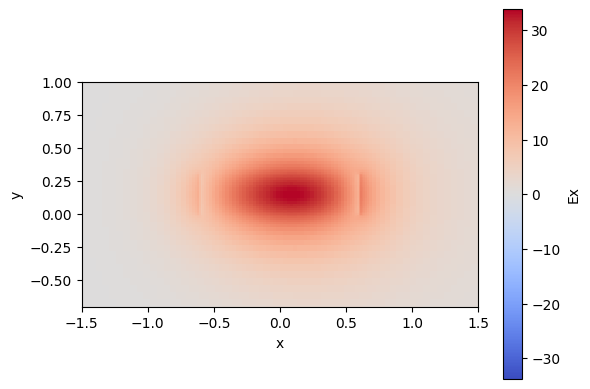

In [41]:
bend_1550 = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=1.2,
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30, 
    bend_radius=20, # Bend radius
)

bend_1550.plot_field(field_name="Ex", 
                     mode_index=0, # Field to be plotted
                     value='real', # Real - abs - imag
                     cmap='coolwarm',
                     xlim=(-1.5, 1.5), # Set the x and y limits
                     ylim=(-0.7, 1)) 

### Mode-mismatch loss

Bend waveguide mode differs slightly from the straight waveguide mode, wich yield into mode-convertion losses. We can calculate this factor with as the overlap of the latter two modes. 

This is already implemented on GDSfactory library: 

  0%|          | 0/10 [00:00<?, ?it/s]

/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/componen

Text(0, 0.5, 'Mismatch (dB)')

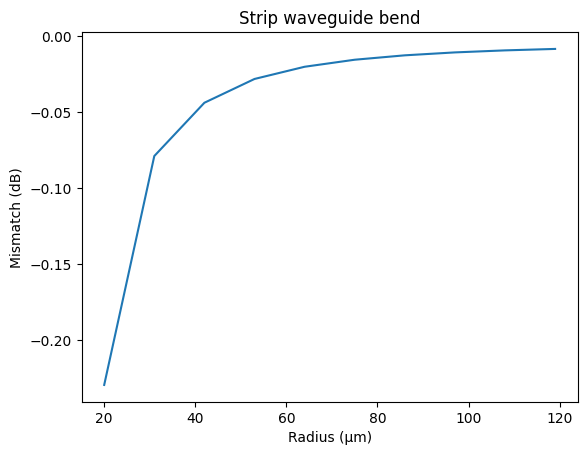

In [42]:
radii = np.arange(20.0, 120,11)

mismatch = gt.modes.sweep_bend_mismatch(bend_1550, radii)

plt.plot(radii, 10 * np.log10(mismatch))
plt.title("Strip waveguide bend")
plt.xlabel("Radius (μm)")
plt.ylabel("Mismatch (dB)")

### Propagation loss

Consider the equivalent linear length of the quarter-circle bend. Light will attenuate following a trend quantified with the experimentally measured parameter $$\alpha [\mathrm{dB}/\mathrm{cm}]$$. It depends on the fabrication process mainly. We will add this loss (in dBs) to the mode-mismatch loss to calculate the total loss per bend. 

*We are not considering the radiation losses, mainly because is not easy to implement a quick simulation for this parameter. Under certain conditions, the main loss sources are the ones considered in this example


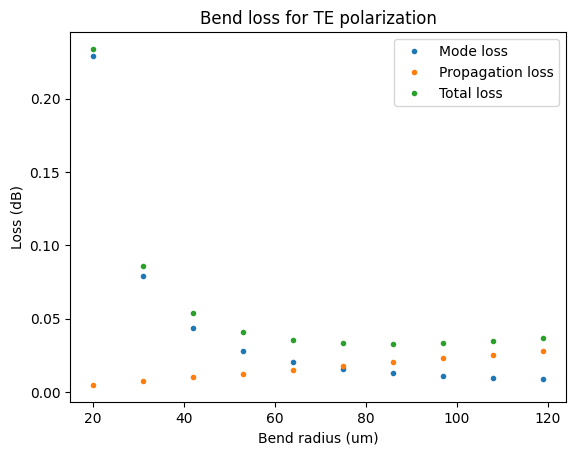

In [43]:
dB_cm = 1.5  # dB/cm Technology loss - 
length = 0.5 * np.pi * radii * 1e-6
propagation_loss = dB_cm * length * 1e2
propagation_loss

plt.title("Bend loss for TE polarization")
plt.plot(radii, -10 * np.log10(mismatch), ".", label="Mode loss")
plt.plot(radii, propagation_loss, ".", label="Propagation loss")
plt.plot(radii, propagation_loss-10 * np.log10(mismatch), ".", label="Total loss")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB)")
plt.legend()

- Use the code provided in this section to calculate the safe radius for 1.2 um width deep waveguides at 1.5 um. Consider safe means less than 0.1 dB/90º

  0%|          | 0/6 [00:00<?, ?it/s]

/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/componen

  0%|          | 0/6 [00:00<?, ?it/s]

2026-03-12 14:03:03.025 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_13f241434025c7df.npz.
2026-03-12 14:03:03.029 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b6ff729f8004f9b5.npz.
2026-03-12 14:03:03.030 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7ea91cd9428d9d0a.npz.
2026-03-12 14:03:03.034 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1e54718f169a6068.npz.
2026-03-12 14:03:03.040 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c22cfd3c8a2199e6.npz.
LO.5 results for the deep waveguide bend at 1550 nm

R (um) | neff_TE0 | Mode loss (dB/90º) | Propagation loss (dB/90º) | Total loss (dB/90º)
    25 | 1.616192 |          0.128365 |                 0.005890 |           0.134255
    50 | 1.614638 |          0.031406 |                 0.011781 |           0.043187
    75 | 1.614402 |          0.015553 |                 0.017

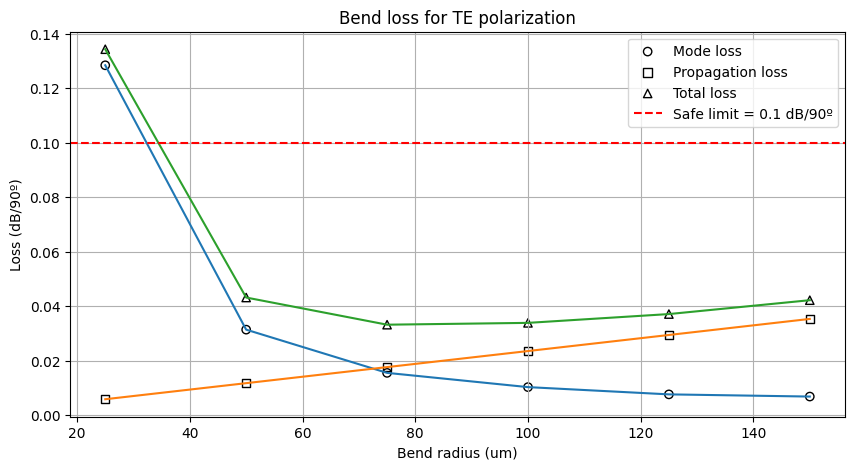

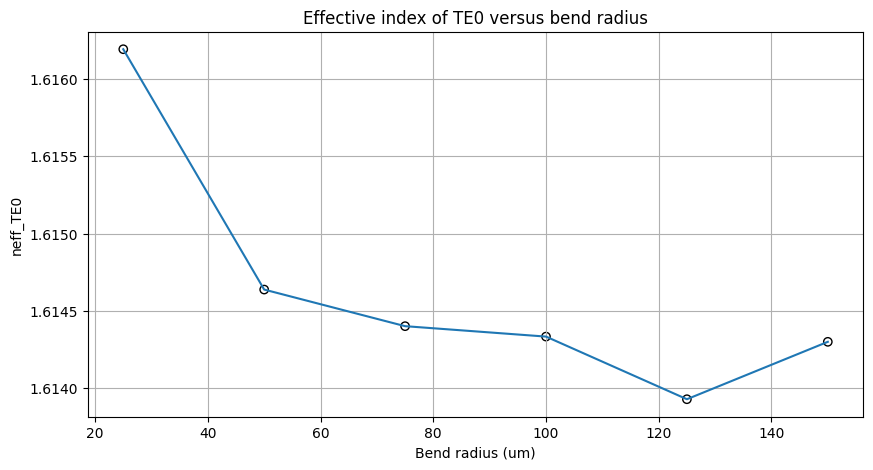

In [44]:
# ===== LO.5 - Additional code required by the statement =====

# Radii requested in the lab book
radii_lo5 = np.array([25, 50, 75, 100, 125, 150], dtype=float)

# 1) Mode-mismatch loss for the required radii
mismatch_lo5 = gt.modes.sweep_bend_mismatch(bend_1550, radii_lo5)
mismatch_lo5 = np.array(mismatch_lo5).squeeze()

mode_loss_lo5 = -10 * np.log10(mismatch_lo5)

# 2) Propagation loss for a 90º bend
dB_cm_lo5 = 1.5
length_lo5 = 0.5 * np.pi * radii_lo5 * 1e-6   # quarter-circle length in meters
propagation_loss_lo5 = dB_cm_lo5 * length_lo5 * 1e2

# 3) Total loss per 90º bend
total_loss_lo5 = mode_loss_lo5 + propagation_loss_lo5

# 4) neff_TE0 versus bend radius
neff_lo5 = gt.modes.sweep_n_eff(bend_1550, bend_radius=radii_lo5)
neff_lo5 = np.array(neff_lo5).squeeze().real

# 5) Print results
print("LO.5 results for the deep waveguide bend at 1550 nm")
print()
print("R (um) | neff_TE0 | Mode loss (dB/90º) | Propagation loss (dB/90º) | Total loss (dB/90º)")
for i in range(len(radii_lo5)):
    print(f"{radii_lo5[i]:6.0f} | {neff_lo5[i]:8.6f} | {mode_loss_lo5[i]:17.6f} | {propagation_loss_lo5[i]:24.6f} | {total_loss_lo5[i]:18.6f}")

# 6) Safe radius
safe_radii_lo5 = radii_lo5[total_loss_lo5 < 0.1]

print()
if len(safe_radii_lo5) > 0:
    print("Safe radii (< 0.1 dB/90º):", safe_radii_lo5)
    print("Minimum safe radius:", safe_radii_lo5[0], "um")
else:
    print("No safe radius found in the simulated range.")

# 7) Loss plot
plt.figure(figsize=(10, 5))
plt.scatter(radii_lo5, mode_loss_lo5, edgecolors='k', facecolors='none', label='Mode loss')
plt.plot(radii_lo5, mode_loss_lo5)

plt.scatter(radii_lo5, propagation_loss_lo5, edgecolors='k', facecolors='none', marker='s', label='Propagation loss')
plt.plot(radii_lo5, propagation_loss_lo5)

plt.scatter(radii_lo5, total_loss_lo5, edgecolors='k', facecolors='none', marker='^', label='Total loss')
plt.plot(radii_lo5, total_loss_lo5)

plt.axhline(0.1, color='r', linestyle='--', label='Safe limit = 0.1 dB/90º')

plt.title("Bend loss for TE polarization")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB/90º)")
plt.grid()
plt.legend()
plt.show()

# 8) neff plot
plt.figure(figsize=(10, 5))
plt.scatter(radii_lo5, neff_lo5, edgecolors='k', facecolors='none')
plt.plot(radii_lo5, neff_lo5)

plt.title("Effective index of TE0 versus bend radius")
plt.xlabel("Bend radius (um)")
plt.ylabel("neff_TE0")
plt.grid()
plt.show()

## EXTRA

All the past simulations were done considering as core material de Silicon Nitride (SiNx) and Silicon Dioxide (SiO2) as cladding material. Now, **simulate the Silicon-On-Insulator technology changing the core material to Silicon (Si)**. In this case, the dimensions will be 220 nm heigth and 500 nm width. 
1. Repeat the LO.2. wavelength behavior simulations, considering the updated materials and dimensions. 
2. Repeat the LO.3. width dependence analysis, now sweeping in a 300nm - 1um range. 
3. Find the safe radius for this technology. Consider sweeping the radius in a 5um to 30um range. 
4. **Compare the SiNx and SOI technologies** 

/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/componen

14:03:46 CET WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 1, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 2, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 3, mode index 3 does not    
             decay at the plane boundaries.                                     

...

             WARNING: Mode field at frequency index 7, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 8, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 9, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 10, mode index 3 does not   
             decay at the plane boundaries.                                     

2026-03-12 14:03:46.562 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_38091c594b211d32.npz.


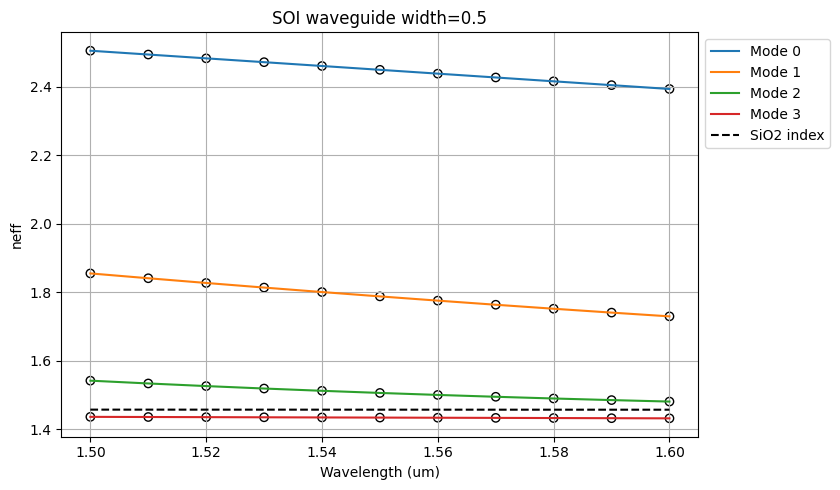

In [45]:
# EXTRA 1 - SOI wavelength behavior

wavelength = np.linspace(1500, 1600, 11) * nm

soi_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=0.5,
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)

soi_res_neff = soi_waveguide.n_eff
soi_res_te = soi_waveguide.fraction_te
soi_res_tm = soi_waveguide.fraction_tm

plt.figure(figsize=(10, 5))
for k in range(soi_res_neff.shape[1]):
    plt.scatter(wavelength, soi_res_neff[:, k].real, edgecolors='k', facecolors='none', label='__nolegend__')
    plt.plot(wavelength, soi_res_neff[:, k].real, label=f'Mode {k}')

plt.title("SOI waveguide width=0.5")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
plt.plot(wavelength, box_index, 'k--', label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

  0%|          | 0/15 [00:00<?, ?it/s]

/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/componen

14:03:50 CET WARNING: Mode field at frequency index 0, mode index 2 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

2026-03-12 14:03:50.859 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_58b0951888c2c7de.npz.


...

2026-03-12 14:05:01.736 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_ee2fc24d63a5f114.npz.


/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/componen

2026-03-12 14:05:03.032 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_07b520dc17f68bb3.npz.


  0%|          | 0/15 [00:00<?, ?it/s]

2026-03-12 14:05:03.055 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_58b0951888c2c7de.npz.
2026-03-12 14:05:03.061 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_4868323f03e12e9d.npz.
2026-03-12 14:05:03.070 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ce81d30082f5cfc5.npz.
2026-03-12 14:05:03.073 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b0b663af0275c2dc.npz.
2026-03-12 14:05:03.084 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_223d93916735b32f.npz.
2026-03-12 14:05:03.092 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_3510de9bd928cebf.npz.
2026-03-12 14:05:03.098 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_401cb9732cf25023.npz.
2026-03-12 14:05:03.109 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_90c1b71feb516776.npz.


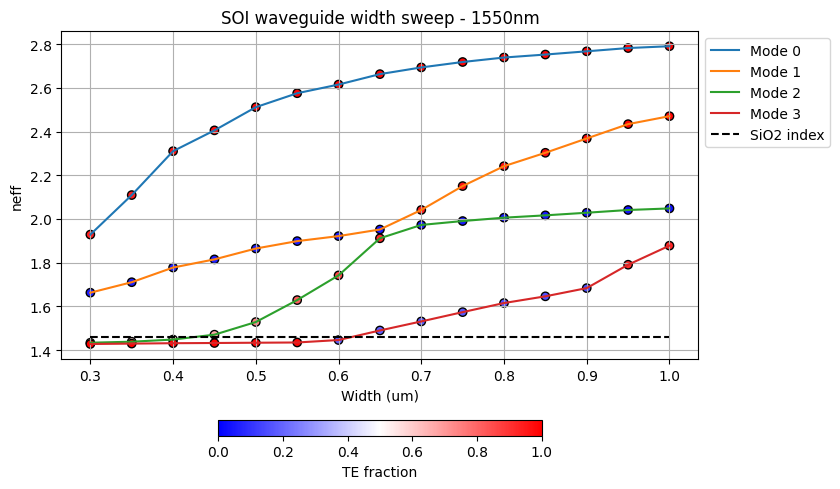

In [46]:
# EXTRA 2 - SOI width sweep

wavelength = 1.55

soi_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=0.5,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)

w_soi = np.linspace(0.3, 1.0, 15)

soi_sweep_neff = gt.modes.sweep_n_eff(
    soi_waveguide,
    core_width=w_soi
)

soi_sweep_tefraction = gt.modes.sweep_fraction_te(
    soi_waveguide,
    core_width=w_soi
)

plt.figure(figsize=(10, 5))
for k in range(soi_sweep_neff.shape[1]):
    plt.scatter(
        w_soi,
        soi_sweep_neff[:, k].real,
        edgecolors='k',
        c=soi_sweep_tefraction.sel(mode_index=k),
        vmin=0,
        vmax=1,
        label='__nolegend__',
        cmap='bwr'
    )
    plt.plot(w_soi, soi_sweep_neff[:, k].real, label=f'Mode {k}')

plt.title("SOI waveguide width sweep - 1550nm")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w_soi), xmax=np.max(w_soi), colors='k', linestyles='dashed', label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal', fraction=0.04).set_label("TE fraction")

  0%|          | 0/26 [00:00<?, ?it/s]

/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/componen

  0%|          | 0/26 [00:00<?, ?it/s]

/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/componen

2026-03-12 14:07:34.878 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_dc3d1854e26bf6af.npz.


...

2026-03-12 14:09:12.372 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_1ba9fa282cd25235.npz.


/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/componen

2026-03-12 14:09:17.297 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_9eadab80b42cc530.npz.


/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/componen

2026-03-12 14:09:19.532 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_702e28b4c8ff6292.npz.
SOI bend results at 1550 nm

R (um) | neff_TE0 | Mode loss (dB/90º) | Propagation loss (dB/90º) | Total loss (dB/90º)
     5 | 2.476910 |          0.012322 |                 0.001178 |           0.013500
     6 | 2.477094 |          0.008519 |                 0.001414 |           0.009932
     7 | 2.477279 |          0.006242 |                 0.001649 |           0.007891
     8 | 2.477448 |          0.004772 |                 0.001885 |           0.006657
     9 | 2.477590 |          0.003764 |                 0.002121 |           0.005885
    10 | 2.477718 |          0.003047 |                 0.002356 |           0.005403
    11 | 2.477828 |          0.002517 |                 0.002592 |           0.005108
    12 | 2.477923 |          0.002113 |                 0.002827 |           0.004940
    13 | 2.478009 |          0.001800 |                 0.003063 |  

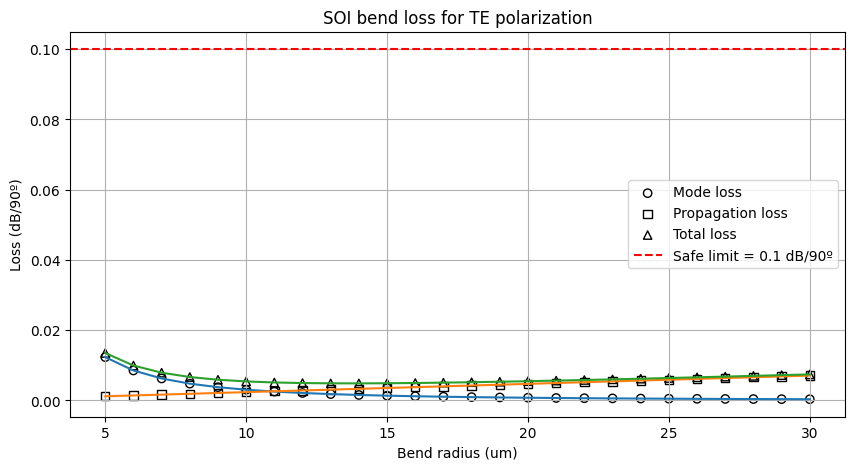

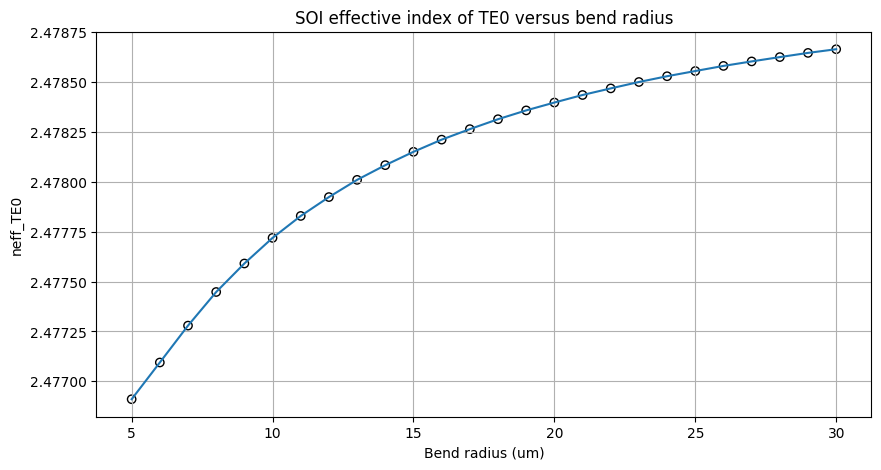

In [47]:
# EXTRA 3 - Safe radius for SOI

soi_bend_1550 = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=0.5,
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30,
    bend_radius=5,
)

radii_soi = np.arange(5.0, 31.0, 1.0)

mismatch_soi = gt.modes.sweep_bend_mismatch(soi_bend_1550, radii_soi)
mismatch_soi = np.array(mismatch_soi).squeeze()

mode_loss_soi = -10 * np.log10(np.abs(mismatch_soi))

dB_cm_soi = 1.5
length_soi = 0.5 * np.pi * radii_soi * 1e-6
propagation_loss_soi = dB_cm_soi * length_soi * 1e2

total_loss_soi = mode_loss_soi + propagation_loss_soi

neff_soi_bend = gt.modes.sweep_n_eff(soi_bend_1550, bend_radius=radii_soi)
neff_soi_bend = np.array(neff_soi_bend).squeeze().real

safe_radii_soi = radii_soi[total_loss_soi < 0.1]

print("SOI bend results at 1550 nm")
print()
print("R (um) | neff_TE0 | Mode loss (dB/90º) | Propagation loss (dB/90º) | Total loss (dB/90º)")
for i in range(len(radii_soi)):
    print(f"{radii_soi[i]:6.0f} | {neff_soi_bend[i]:8.6f} | {mode_loss_soi[i]:17.6f} | {propagation_loss_soi[i]:24.6f} | {total_loss_soi[i]:18.6f}")

print()
if len(safe_radii_soi) > 0:
    print("Safe radii (< 0.1 dB/90º):", safe_radii_soi)
    print("Minimum safe radius:", safe_radii_soi[0], "um")
else:
    print("No safe radius found in the simulated range.")

plt.figure(figsize=(10, 5))
plt.scatter(radii_soi, mode_loss_soi, edgecolors='k', facecolors='none', label='Mode loss')
plt.plot(radii_soi, mode_loss_soi)

plt.scatter(radii_soi, propagation_loss_soi, edgecolors='k', facecolors='none', marker='s', label='Propagation loss')
plt.plot(radii_soi, propagation_loss_soi)

plt.scatter(radii_soi, total_loss_soi, edgecolors='k', facecolors='none', marker='^', label='Total loss')
plt.plot(radii_soi, total_loss_soi)

plt.axhline(0.1, color='r', linestyle='--', label='Safe limit = 0.1 dB/90º')
plt.title("SOI bend loss for TE polarization")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB/90º)")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(radii_soi, neff_soi_bend, edgecolors='k', facecolors='none')
plt.plot(radii_soi, neff_soi_bend)
plt.title("SOI effective index of TE0 versus bend radius")
plt.xlabel("Bend radius (um)")
plt.ylabel("neff_TE0")
plt.grid()
plt.show()

2026-03-12 14:09:19.861 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_651c08b700f375c8.npz.


/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/componen

2026-03-12 14:09:39.282 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_792f6eacfc235c88.npz.


  0%|          | 0/6 [00:00<?, ?it/s]

/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/pablo/cifoin/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/componen

Comparison between SiNx and SOI

SiNx deep waveguide (300 nm x 1.2 um)   -> neff_TE0 at 1550 nm = 1.604917
SOI strip waveguide (220 nm x 0.5 um)   -> neff_TE0 at 1550 nm = 2.449872

SiNx safe radius (< 0.1 dB/90º): 50.0 um
SOI safe radius (< 0.1 dB/90º): 5.0 um


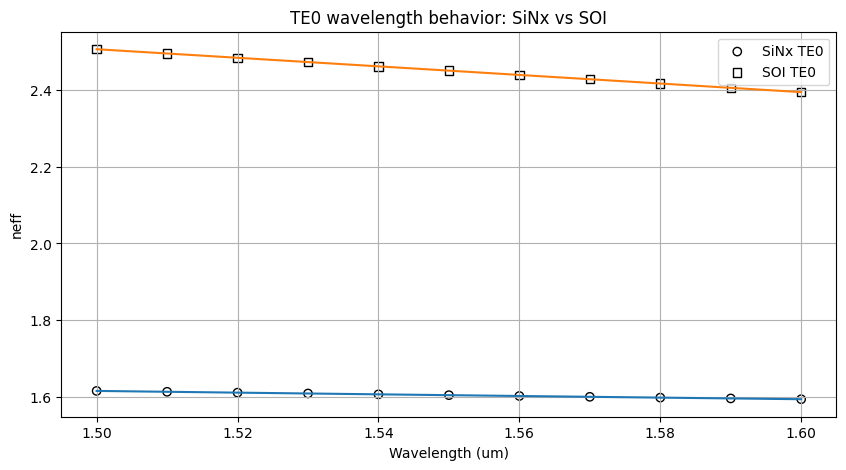

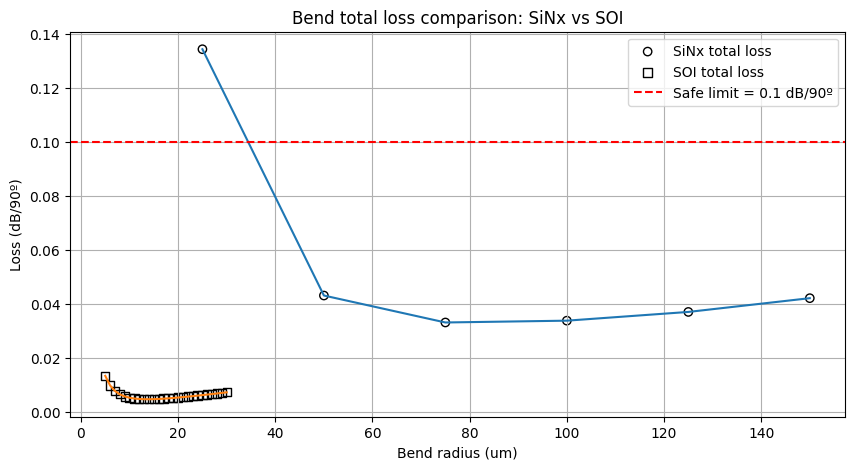

In [48]:
# EXTRA 4 - Compare SiNx and SOI technologies

# --- SiNx deep waveguide (original technology) ---
wavelength_compare = np.linspace(1500, 1600, 11) * nm

sinx_waveguide_compare = gt.modes.Waveguide(
    wavelength=wavelength_compare,
    core_width=1.2,
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=2,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)

sinx_neff_compare = sinx_waveguide_compare.n_eff

# --- SOI waveguide (extra) ---
soi_waveguide_compare = gt.modes.Waveguide(
    wavelength=wavelength_compare,
    core_width=0.5,
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=2,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)

soi_neff_compare = soi_waveguide_compare.n_eff

# --- Nominal neff comparison ---
sinx_neff_1550 = sinx_neff_compare[5, 0].real
soi_neff_1550 = soi_neff_compare[5, 0].real

# --- Safe radius comparison ---
sinx_bend_compare = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=1.2,
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30,
    bend_radius=25,
)

radii_sinx = np.array([25, 50, 75, 100, 125, 150], dtype=float)

mismatch_sinx = gt.modes.sweep_bend_mismatch(sinx_bend_compare, radii_sinx)
mismatch_sinx = np.array(mismatch_sinx).squeeze()

mode_loss_sinx = -10 * np.log10(np.abs(mismatch_sinx))

dB_cm_sinx = 1.5
length_sinx = 0.5 * np.pi * radii_sinx * 1e-6
propagation_loss_sinx = dB_cm_sinx * length_sinx * 1e2

total_loss_sinx = mode_loss_sinx + propagation_loss_sinx
safe_radii_sinx = radii_sinx[total_loss_sinx < 0.1]

print("Comparison between SiNx and SOI")
print()
print(f"SiNx deep waveguide (300 nm x 1.2 um)   -> neff_TE0 at 1550 nm = {sinx_neff_1550:.6f}")
print(f"SOI strip waveguide (220 nm x 0.5 um)   -> neff_TE0 at 1550 nm = {soi_neff_1550:.6f}")
print()

if len(safe_radii_sinx) > 0:
    print("SiNx safe radius (< 0.1 dB/90º):", safe_radii_sinx[0], "um")
else:
    print("SiNx safe radius (< 0.1 dB/90º): not found in the simulated range")

if len(safe_radii_soi) > 0:
    print("SOI safe radius (< 0.1 dB/90º):", safe_radii_soi[0], "um")
else:
    print("SOI safe radius (< 0.1 dB/90º): not found in the simulated range")

plt.figure(figsize=(10, 5))
plt.scatter(wavelength_compare, sinx_neff_compare[:, 0].real, edgecolors='k', facecolors='none', label='SiNx TE0')
plt.plot(wavelength_compare, sinx_neff_compare[:, 0].real)

plt.scatter(wavelength_compare, soi_neff_compare[:, 0].real, edgecolors='k', facecolors='none', marker='s', label='SOI TE0')
plt.plot(wavelength_compare, soi_neff_compare[:, 0].real)

plt.title("TE0 wavelength behavior: SiNx vs SOI")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(radii_sinx, total_loss_sinx, edgecolors='k', facecolors='none', label='SiNx total loss')
plt.plot(radii_sinx, total_loss_sinx)

plt.scatter(radii_soi, total_loss_soi, edgecolors='k', facecolors='none', marker='s', label='SOI total loss')
plt.plot(radii_soi, total_loss_soi)

plt.axhline(0.1, color='r', linestyle='--', label='Safe limit = 0.1 dB/90º')
plt.title("Bend total loss comparison: SiNx vs SOI")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB/90º)")
plt.grid()
plt.legend()
plt.show()

## Grading

LO.1. 1 Point <br> 
LO.2. 2 Points <br> 
LO.3. 1 Point <br> 
LO.4. 2 Points <br> 
LO.5. 1 Point <br> 
**Total 7 Points** <br>
Extra (Up to) 3 Points
